# Day 3 - Solutions

## Problem 1 - Plotting data
In the first section of this problem you can either write something to import it line by line, but it is definitely more appropriate to use Numpys `genfromtxt()` function to read in the data. I would also recommend instead of reading in the files individually, using a loop to read them in instead.

In [30]:
# Declare what libraries to import
import matplotlib.pyplot as plt
import numpy as np

# A short function to read in the data from the CSV files, reuturning the time,
# effective tempreature and luminosity as different arrays, this is not stictly
# neccessary but makes the code a bit cleaner
def read_data(file_path):
  data = np.genfromtxt(file_path, delimiter=",")
  return data[:, 0], data[:, 1], data[:, 2]

# List the star masses we want to read in the data for
masses = [1,2,4,8,16]


Here is a rudimentary way of solving the first half of the problem, but keep in mind that this doesn't format the resultant plot, and is mostly hard-coded, and not very flexible.

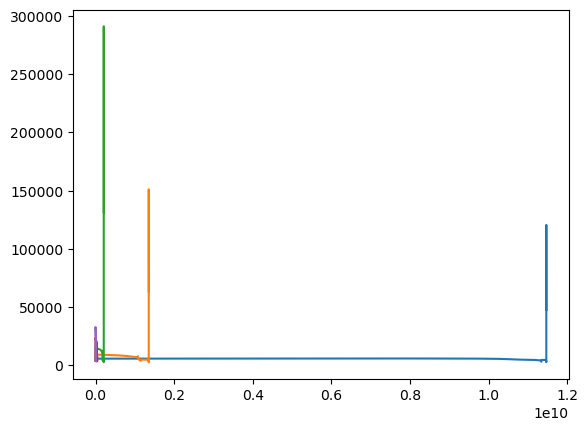

In [31]:
# In this version, we will perform a very rudimentary version of the plot, 
# whilst this works, it is not as efficient as it could be

t_1, T_eff_1, L_1 = read_data("star_1_msol.csv")
t_2, T_eff_2, L_2 = read_data("star_2_msol.csv")
t_4, T_eff_4, L_4 = read_data("star_4_msol.csv")
t_8, T_eff_8, L_8 = read_data("star_8_msol.csv")
t_16, T_eff_16, L_16 = read_data("star_16_msol.csv")

# Storing the data in this way is not ideal, as it hard-coded, and not very
# flexible.

# In addition, while the data is plotted out, it is not labelled and the scale
# is inappropriate for the data, we will fix this in the next version.

plt.plot(t_1, T_eff_1, label="1 Msol")
plt.plot(t_2, T_eff_2, label="2 Msol")
plt.plot(t_4, T_eff_4, label="4 Msol")
plt.plot(t_8, T_eff_8, label="8 Msol")
plt.plot(t_16, T_eff_16, label="16 Msol")
plt.show()

A better version of this plot, where the data is read and lines are plotted within a loop, and the resultant plot is correctly formatted.

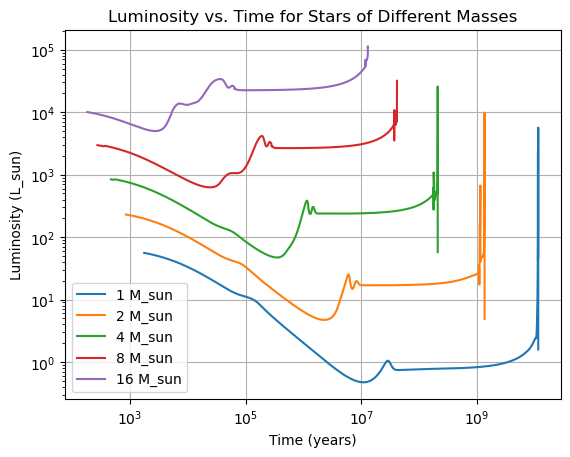

In [32]:
# Loop through the masses to read in the data for each star and then plot the
# luminosity vs. time for each star, calling plot repeatedly makes a new line
# with its own color, the label argument is used to create a legend later
for mass in masses:
  t, T_eff, L = read_data(f"star_{mass}_msol.csv") # Read in the files, using an f-string to make the right filename for each mass
  plt.plot(t, L, label=f"{mass} M_sun") # Plot the luminosity vs. time
# Now we work on the labels and formatting of the plot, it is good to get into
# the habit of labelling and scaling your plots properly now
plt.xlabel("Time (years)") # Label the x-axis
plt.xscale("log") # Turn the x-axis into a log scale
plt.ylabel("Luminosity (L_sun)") # Same, with the y-axis
plt.yscale("log") # Same, with the y-axis
plt.title("Luminosity vs. Time for Stars of Different Masses") # Add a title to the plot
plt.legend() # Add a legend, you don't need to add any arguments as the labels have already been set in the plot command, and the legend will automatically use them, though sometimes it might put the legend in the wrong place without input!
plt.grid() # Add a grid to the plot, very optional
plt.show() # Finish up and show the plot, you can also write it to the disk with plt.savefig("filename.pdf") if you want to save it as a file, but this is better for notebooks


Producing the HR diagram is roughly the same, so I'll write it in a way that uses the `loglog()` function instead of `plot()`, which acts as a shorthand for defining the axes scales afterwards.

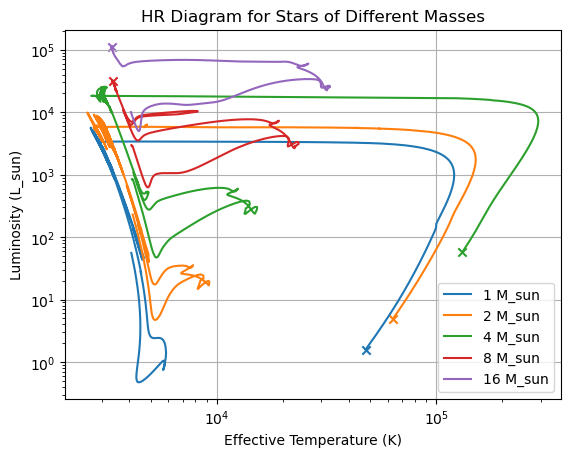

In [33]:
# After plt.show() is run, a new plot is started, so we don't have to clear up
# the old one

# As before, we loop through the masses, but with a different plot command using
# different data, keep in mind that I have called read_data again, this is not
# very efficient, but it is easier to read at this stage and the files are quite
# small
for mass in masses:
  t, T_eff, L = read_data(f"star_{mass}_msol.csv")
  plt.loglog(T_eff, L, label=f"{mass} M_sun") # Using loglog instead, which makes both axes log scale, this is a shorthand version of what we did previously
  plt.scatter(T_eff[-1], L[-1], marker="x")  # Mark the end of the main sequence
# As before, after the loop, we add the labels and format the plot
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Luminosity (L_sun)")
plt.title("HR Diagram for Stars of Different Masses")
plt.legend()
plt.grid()
plt.show()

## Problem 2 - Fitting data

First, we read in our data, this is similar to how we did this in previous problems, however, we will be _unpacking_ the data into arrays representing a column of data, this makes the code a bit easier to read but isn't required.

In [34]:
# Declare libraries 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Read in data
data = np.genfromtxt("oscillator.csv", delimiter=",", skip_header=1) 
# Unpack data into arrays
t = data[:, 0]
x = data[:, 1] 

Next, we define the function we need to fit the line (`damped_curve()`) which has the variables we want to fit as the arguments, note that `t` is the first argument, as this is the data being fed into the function. We also define a section function, `exponential_decay()`, which will be used to plot the amplitude decay lines when we have made estimates.

In [35]:
# Define the function we want to fit to the data
def damped_curve(t, A, gamma, omega_d, delta):
    return A * np.exp(-gamma * t / 2) * np.cos(omega_d * t + delta)

# Define an exponential decay function used to plot the envelope of the oscillation curve
def exponential_decay(t, A, gamma):
    return A * np.exp(-gamma * t / 2)

We now fit the data, first by making initial guesses that are within an order of magnitude or two of the actual value. While this doesn't have to be done for this problem, it is generally good practice to do so. `popt` contains the optimized parameters in the order they were fed into the fitting function, so $[A,\gamma,\omega_d,\delta]$, while `pcov` is a matrix containing the covariance values between each parameter. The reasoning behind this is beyond the scope of this project, but you can calculate the uncertainties of these parameter fits by diagonalizing the matrix to find the variance, and then taking the square root of the variance values to calculate the uncertainties. This is straightforward to do in `numpy`.

In [36]:
# Define initial guesses
p0 = [1,1,1,1] # Initial guesses for the parameters, these are not very good, but do not need to be accurate, as long as they are within the right order of magnitudem, this isn't strictly necessary for this problem but it is good practice
popt,pcov = curve_fit(damped_curve, t, x, p0=p0) # Calculate the optimal parameters and the covariance matrix
# Caclulate uncertainties on fitted parameters, by diagonalizing the covariance matrix (pcov) and taking the square root of the diagonal elements, giving the standard deviation
diag = np.diag(pcov) # Diagonialize the covariance matrix, giving us the variance of each parameter
err = np.sqrt(diag) # Finally, square rooting will calculate the uncertainty 

Now that we have found $\gamma$ and $\omega_d$, we can use those to calculate $\omega_0$

In [37]:

gamma = popt[1]
omega_d = popt[2]
omega_0 = np.sqrt(omega_d**2 + (gamma/2)**2)

Now, we print the fitted parameters for the user, we're using a slightly nicer way of formatting that looks a lot cleaner to the end-user.

In [38]:
# Print the fitted parameters and their uncertainties
# These are printed with a bit of formattting to align the values, making it easy to read, the >6.3f means to print the number with 3 decimal places, aligning it to the right with 6 total characters
# Check this for more information: https://realpython.com/how-to-python-f-string-format-float/#customizing-the-width-of-your-formatted-strings
print("Fitted parameters:")
print(f"A   = {popt[0]:>6.3f} ± {err[0]:.3f}")
print(f"γ   = {popt[1]:>6.3f} ± {err[1]:.3f}")
print(f"ω_d = {popt[2]:>6.3f} ± {err[2]:.3f}")
print(f"δ   = {popt[3]:>6.3f} ± {err[3]:.3f}")

Fitted parameters:
A   =  0.883 ± 0.007
γ   =  1.612 ± 0.017
ω_d =  7.263 ± 0.008
δ   = -2.473 ± 0.007


**However**, if we wanted to calculate the uncertainty of $\omega_0$, you can either perform an error propagation manually (difficult), or, a Python library exists for this kind of thing: [`uncertainties`](https://pythonhosted.org/uncertainties/). `uncertainties` uses special versions of `float` types to store the value as well as its uncertainty, and propagates errors automatically. It's very useful and saves a lot of time.

In [39]:
from uncertainties import ufloat
gamma_u = ufloat(popt[1], err[1])
omega_d_u = ufloat(popt[2], err[2])
omega_0_u = (omega_d_u**2 + (gamma_u/2)**2) ** 0.5
print(f"gamma = {gamma_u}")
print(f"omega_d = {omega_d_u}")
print(f"omega_0 = {omega_0_u}")

gamma = 1.612+/-0.017
omega_d = 7.263+/-0.008
omega_0 = 7.308+/-0.008


Now we plot our results. We use a scatter plot for the data to show that this is our instrumented data, a bold line for the fit so that it stands out, our amplitude curves as differing colors, and we include our values for $\gamma$ and $\omega_0$ in the title as well as our correctly propagated uncertainties.

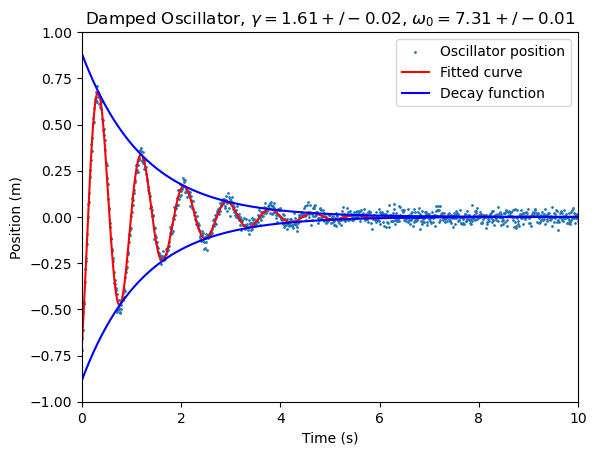

In [40]:
# Plot resultant data
plt.scatter(t, x, s=1, label="Oscillator position") 
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.xlim(0,10)
plt.ylim(-1,1)
plt.plot(t, damped_curve(t, *popt), color="red", label="Fitted curve") # Plot the fitted curve, using the optimized parameters, the * is used to unpack the array into a list of arguments for the function, though it can be called with popt[0], popt[1] etc.
# Plot the envelope of the curve
plt.plot(t, exponential_decay(t, popt[0], popt[1]), color="blue", label="Decay function")
plt.plot(t, -exponential_decay(t, popt[0], popt[1]), color="blue")
plt.title(f"Damped Oscillator, $\gamma={gamma_u:.2f}$, $\omega_0={omega_0_u:.2f}$")
plt.legend()
# Show plot, finish!
plt.show()

## Problem 3 - Reading images

### Part 1
This is more of a way of showing you how `imshow` works. The `mpimg` functions in `matplotlib` can decode most image files.

Text(0.5, 1.0, "Hey look, it's the Earth!")

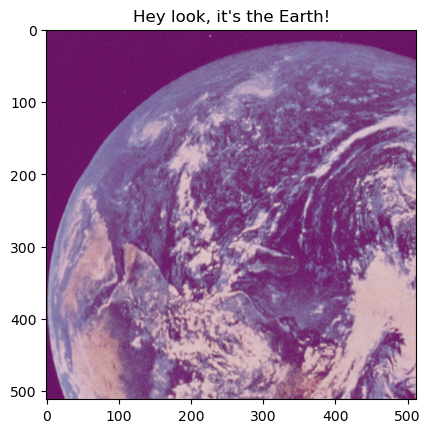

In [41]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
filename = "sipi.tiff"
img = mpimg.imread(filename)
plt.imshow(img)
plt.title("Hey look, it's the Earth!")

### Part 2
Now that you have an idea of how to use `imshow`, we will make a more complex version of this program to read FITs files.

Filename: hst_11137_01_wfpc2_total_wf_drz.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1214   ()      
  1  SCI           1 ImageHDU       103   (2150, 2150)   float32   
  2  WHT           1 ImageHDU       124   (2150, 2150)   float32   
  3  CTX           1 ImageHDU       123   (2150, 2150)   int32   
None
XTENSION IMAGE
BITPIX -32
NAXIS 2
NAXIS1 2150
NAXIS2 2150
PCOUNT 0
GCOUNT 1
CRVAL1 287.8782164216667
CRVAL2 16.86331641638889
CRPIX1 1075.0
CRPIX2 1075.0
CD1_1 -2.777777777777778e-05
CD1_2 0.0
CD2_1 0.0
CD2_2 2.777777777777778e-05
DATAMIN -443.4219
DATAMAX 57597.91
VAFACTOR 1.0
MIR_REVR True
ORIENTAT 0.0
FILLCNT 0
ERRCNT 0
FPKTTIME 54638.65973399999
LPKTTIME 54638.65990000001
CTYPE1 RA---TAN
CTYPE2 DEC--TAN
DETECTOR 1
DEZERO 320.4959
BIASEVEN 320.5174
BIASODD 320.4744
BIASEVNU 320.5174
BIASODDU 320.4744
GOODMIN -73.00857
GOODMAX 3610.663
DATAMEAN 2.535382
GPIXELS 552726
SOFTERRS 0
CALIBDEF 82637
STATICD 0
ATODSAT 16
DATALO

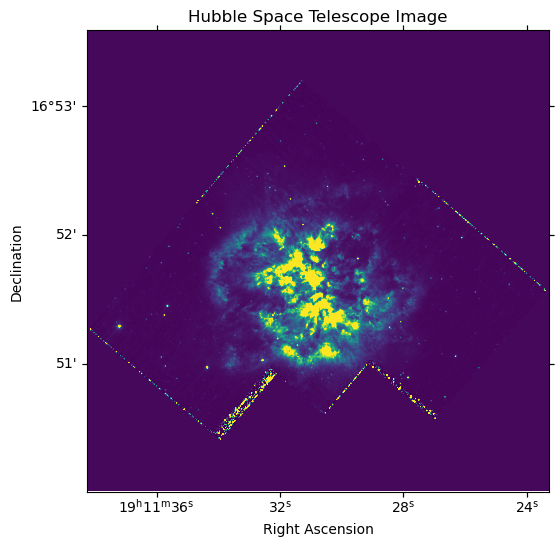

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
# Load the FITS file
fits_file = fits.open("hst_11137_01_wfpc2_total_wf_drz.fits.gz") # Read in the FITS file
# Extract the image data and header
# Note that the image data is in the second extension of the FITS file
print(fits_file.info()) # This is a useful command to see what is in the FITS file, it will show you the different extensions and what they contain, this is very useful for figuring out where the data you want is located

for i in fits_file[1].header:
    print(i, fits_file[1].header[i])

header = fits_file[1].header # The header contains the metadata for the image, including the WCS co-ordinate data
image_data = fits_file[1].data # The data itself is stored here in the form of a 2D array with brightness values
# Create a figure with WCS projection
wcs = WCS(header) # Get the WCS information from the header
fig = plt.figure(figsize=(8, 6)) # Create a new figure, you don't need to do this if you are using plt.imshow() directly, but it is useful if you want to add a WCS projection, as we do here
ax = fig.add_subplot(111, projection=wcs) # We add a sub-plot to the figure, and make it a WCS projection
# Plot the image, we are using ax instead of plt as we want to modify the sub-plot we just created!

# Get the 1st and 99th percentiles of the image data, as this brings out the features of the image better
vmin = np.percentile(image_data, 1) # Get the 1st percentile of the image data
vmax = np.percentile(image_data, 99) # Get the 99th percentile of the image data

# Plot the image, I'm using a new line for each argument to make it easier to read, but it could be done in one line
ax.imshow(image_data,origin="lower", # Image data is stored in the form of a 2D array, but we need to flip the image to get the correct orientation, unlike the previous image we made
          vmin=vmin, # Use our vmin value for the minimum brightness
          vmax=vmax # Use our vmax value for the maximum brightness)
)
# Label our axes appropriately, we don't have to do anything else to get the correct units
ax.set_xlabel('Right Ascension') 
ax.set_ylabel('Declination')
# Add a title, then show
plt.title('Hubble Space Telescope Image')
plt.show() # Show the plot

As you can see in the text output, there are multiple tables, we are using no. 1, SCI, which contains the image table in the form of a 2150x2150 array, which is converted into a Numpy array by astropy.